<a href="https://colab.research.google.com/github/Hetvi48/Health-Insurance-claim-prediction-model/blob/main/insurance_miniPro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Import required Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.compose import make_column_selector, make_column_transformer
from sklearn.pipeline import make_pipeline

In [ ]:
sklearn.set_config(display = 'diagram')

# Data Loading

In [ ]:
df = pd.read_csv('drive/MyDrive/ML_miniProjects/insurance.csv')

# Data info

In [ ]:
df.head()

,age,sex,weight,bmi,hereditary_diseases,no_of_dependents,smoker,city,bloodpressure,diabetes,regular_ex,job_title,claim
0,60.0,male,64,24.3,NoDisease,1,0,NewYork,72,0,0,Actor,13112.6
1,49.0,female,75,22.6,NoDisease,1,0,Boston,78,1,1,Engineer,9567.0
2,32.0,female,64,17.8,Epilepsy,2,1,Phildelphia,88,1,1,Academician,32734.2
3,61.0,female,53,36.4,NoDisease,1,1,Pittsburg,72,1,0,Chef,48517.6
4,19.0,female,50,20.6,NoDisease,0,0,Buffalo,82,1,0,HomeMakers,1731.7


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  14604 non-null  float64
 1   sex                  15000 non-null  object 
 2   weight               15000 non-null  int64  
 3   bmi                  14044 non-null  float64
 4   hereditary_diseases  15000 non-null  object 
 5   no_of_dependents     15000 non-null  int64  
 6   smoker               15000 non-null  int64  
 7   city                 15000 non-null  object 
 8   bloodpressure        15000 non-null  int64  
 9   diabetes             15000 non-null  int64  
 10  regular_ex           15000 non-null  int64  
 11  job_title            15000 non-null  object 
 12  claim                15000 non-null  float64
dtypes: float64(3), int64(6), object(4)
memory usage: 1.5+ MB


In [ ]:
df.describe()

,age,weight,bmi,no_of_dependents,smoker,bloodpressure,diabetes,regular_ex,claim
count,14604.000000,15000.000000,14044.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,39.547521,64.909600,30.266413,1.129733,0.198133,68.650133,0.777000,0.224133,13401.437620
std,14.015966,13.701935,6.122950,1.228469,0.398606,19.418515,0.416272,0.417024,12148.239619
min,18.000000,34.000000,16.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1121.900000
25%,27.000000,54.000000,25.700000,0.000000,0.000000,64.000000,1.000000,0.000000,4846.900000
50%,40.000000,63.000000,29.400000,1.000000,0.000000,71.000000,1.000000,0.000000,9545.650000
75%,52.000000,76.000000,34.400000,2.000000,0.000000,80.000000,1.000000,0.000000,16519.125000
max,64.000000,95.000000,53.100000,5.000000,1.000000,122.000000,1.000000,1.000000,63770.400000


In [ ]:
df.isnull().sum()

,0
age,396
sex,0
weight,0
bmi,956
hereditary_diseases,0
no_of_dependents,0
smoker,0
city,0
bloodpressure,0
diabetes,0


# Filling null values

In [ ]:
imputer = SimpleImputer(strategy = 'median')
imputer.fit(df.select_dtypes(include = [np.number]))

SimpleImputer(strategy='median')

In [ ]:
df[df.select_dtypes(include = [np.number]).columns] = imputer.transform(df.select_dtypes(include = [np.number]))

In [ ]:
df.isnull().sum()

,0
age,0
sex,0
weight,0
bmi,0
hereditary_diseases,0
no_of_dependents,0
smoker,0
city,0
bloodpressure,0
diabetes,0


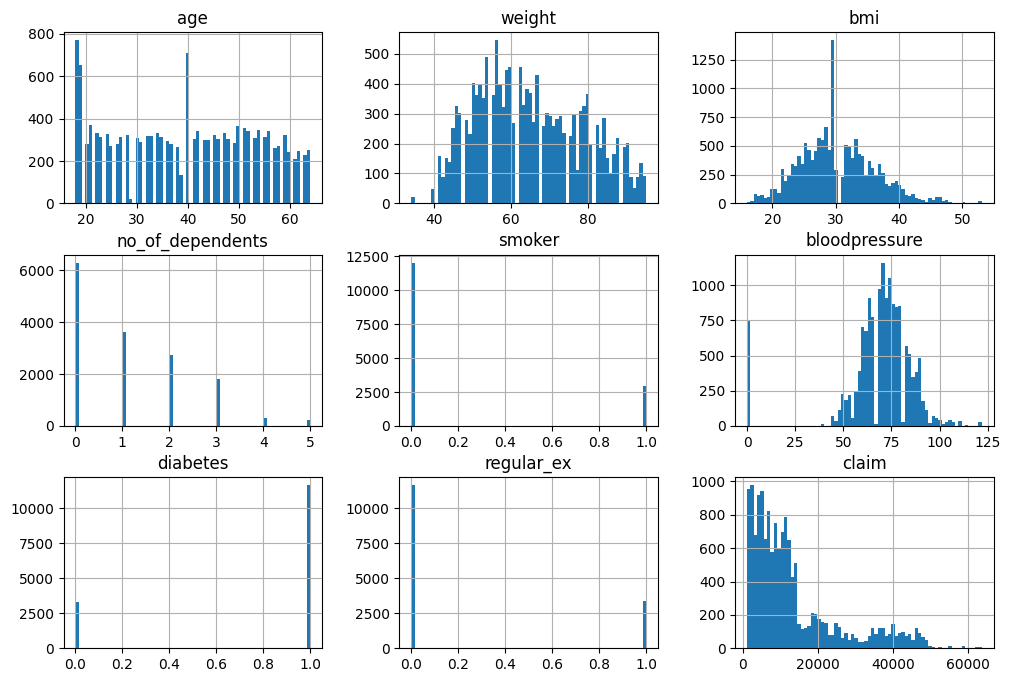

In [ ]:
df.hist(bins=70, figsize=(12,8))
plt.show()

<Axes: xlabel='weight', ylabel='bmi'>

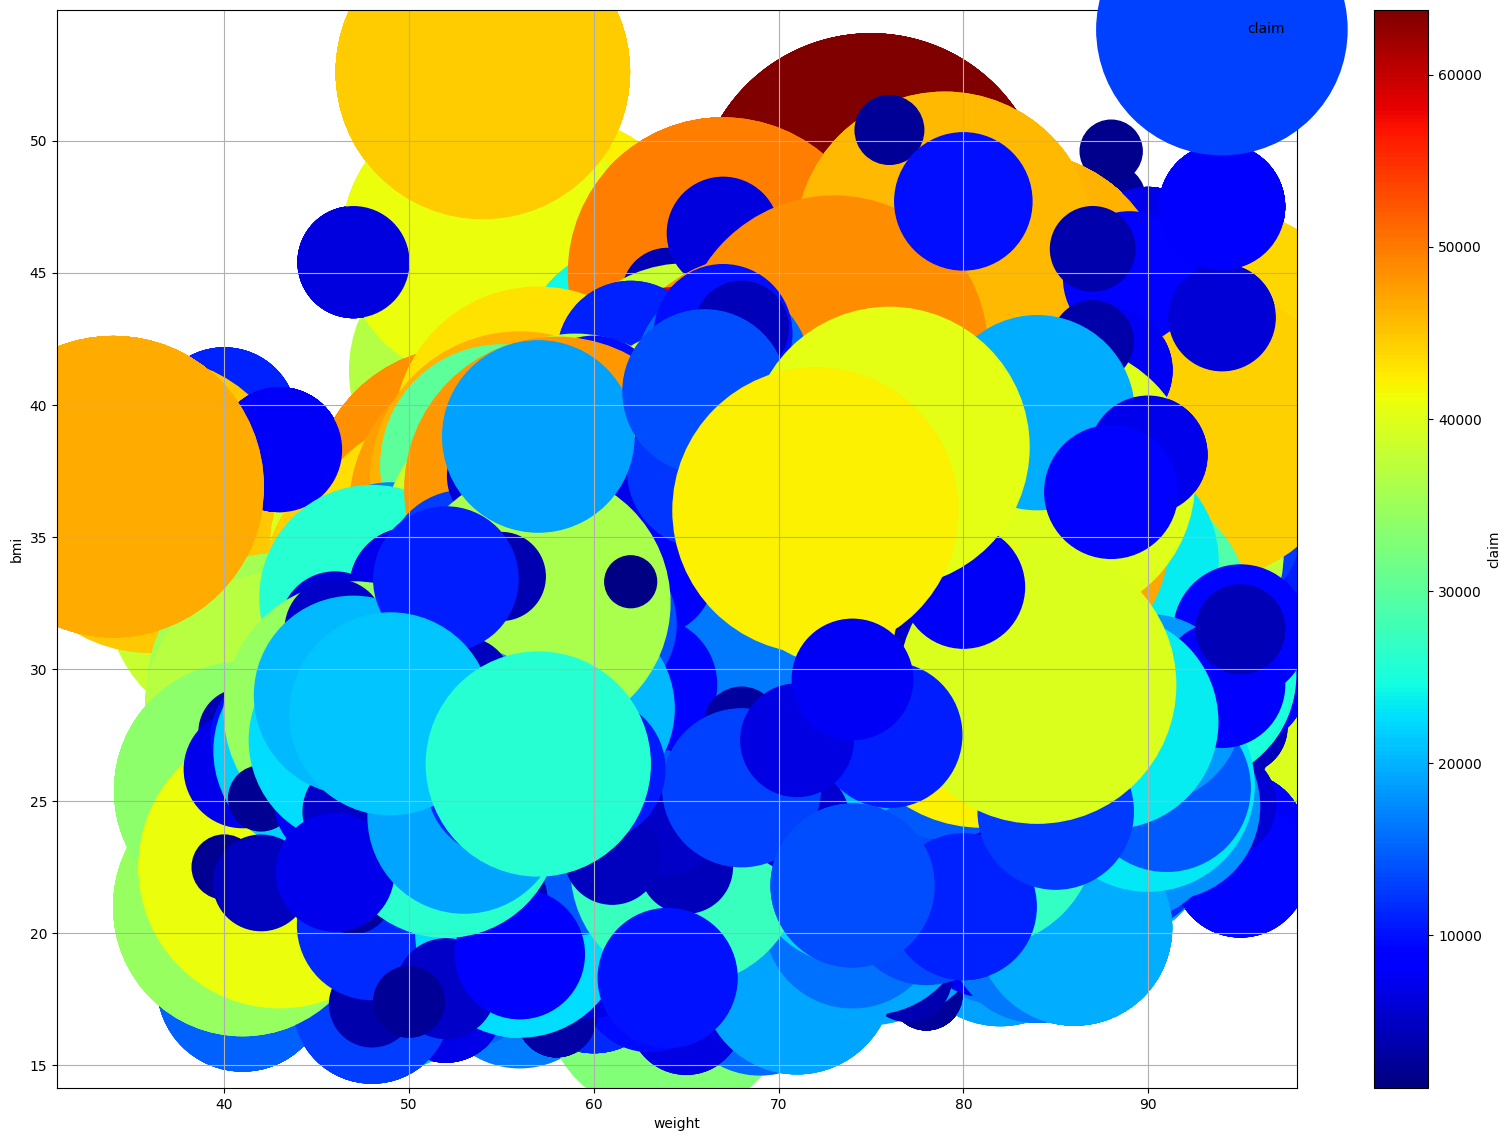

In [ ]:
df.plot(
    kind = "scatter", x = "weight", y = "bmi",
    grid = True,
    s = df['claim'], label = 'claim',
    c = "claim", cmap = "jet", colorbar = True,
    legend = True, sharex = False, figsize = (20,14)
)

In [ ]:
from pandas.plotting import scatter_matrix

In [ ]:
attributes = ['age', 'weight', 'bmi', 'bloodpressure', 'claim']

array([[<Axes: xlabel='age', ylabel='age'>,
        <Axes: xlabel='weight', ylabel='age'>,
        <Axes: xlabel='bmi', ylabel='age'>,
        <Axes: xlabel='bloodpressure', ylabel='age'>,
        <Axes: xlabel='claim', ylabel='age'>],
       [<Axes: xlabel='age', ylabel='weight'>,
        <Axes: xlabel='weight', ylabel='weight'>,
        <Axes: xlabel='bmi', ylabel='weight'>,
        <Axes: xlabel='bloodpressure', ylabel='weight'>,
        <Axes: xlabel='claim', ylabel='weight'>],
       [<Axes: xlabel='age', ylabel='bmi'>,
        <Axes: xlabel='weight', ylabel='bmi'>,
        <Axes: xlabel='bmi', ylabel='bmi'>,
        <Axes: xlabel='bloodpressure', ylabel='bmi'>,
        <Axes: xlabel='claim', ylabel='bmi'>],
       [<Axes: xlabel='age', ylabel='bloodpressure'>,
        <Axes: xlabel='weight', ylabel='bloodpressure'>,
        <Axes: xlabel='bmi', ylabel='bloodpressure'>,
        <Axes: xlabel='bloodpressure', ylabel='bloodpressure'>,
        <Axes: xlabel='claim', ylabel='bloodpres

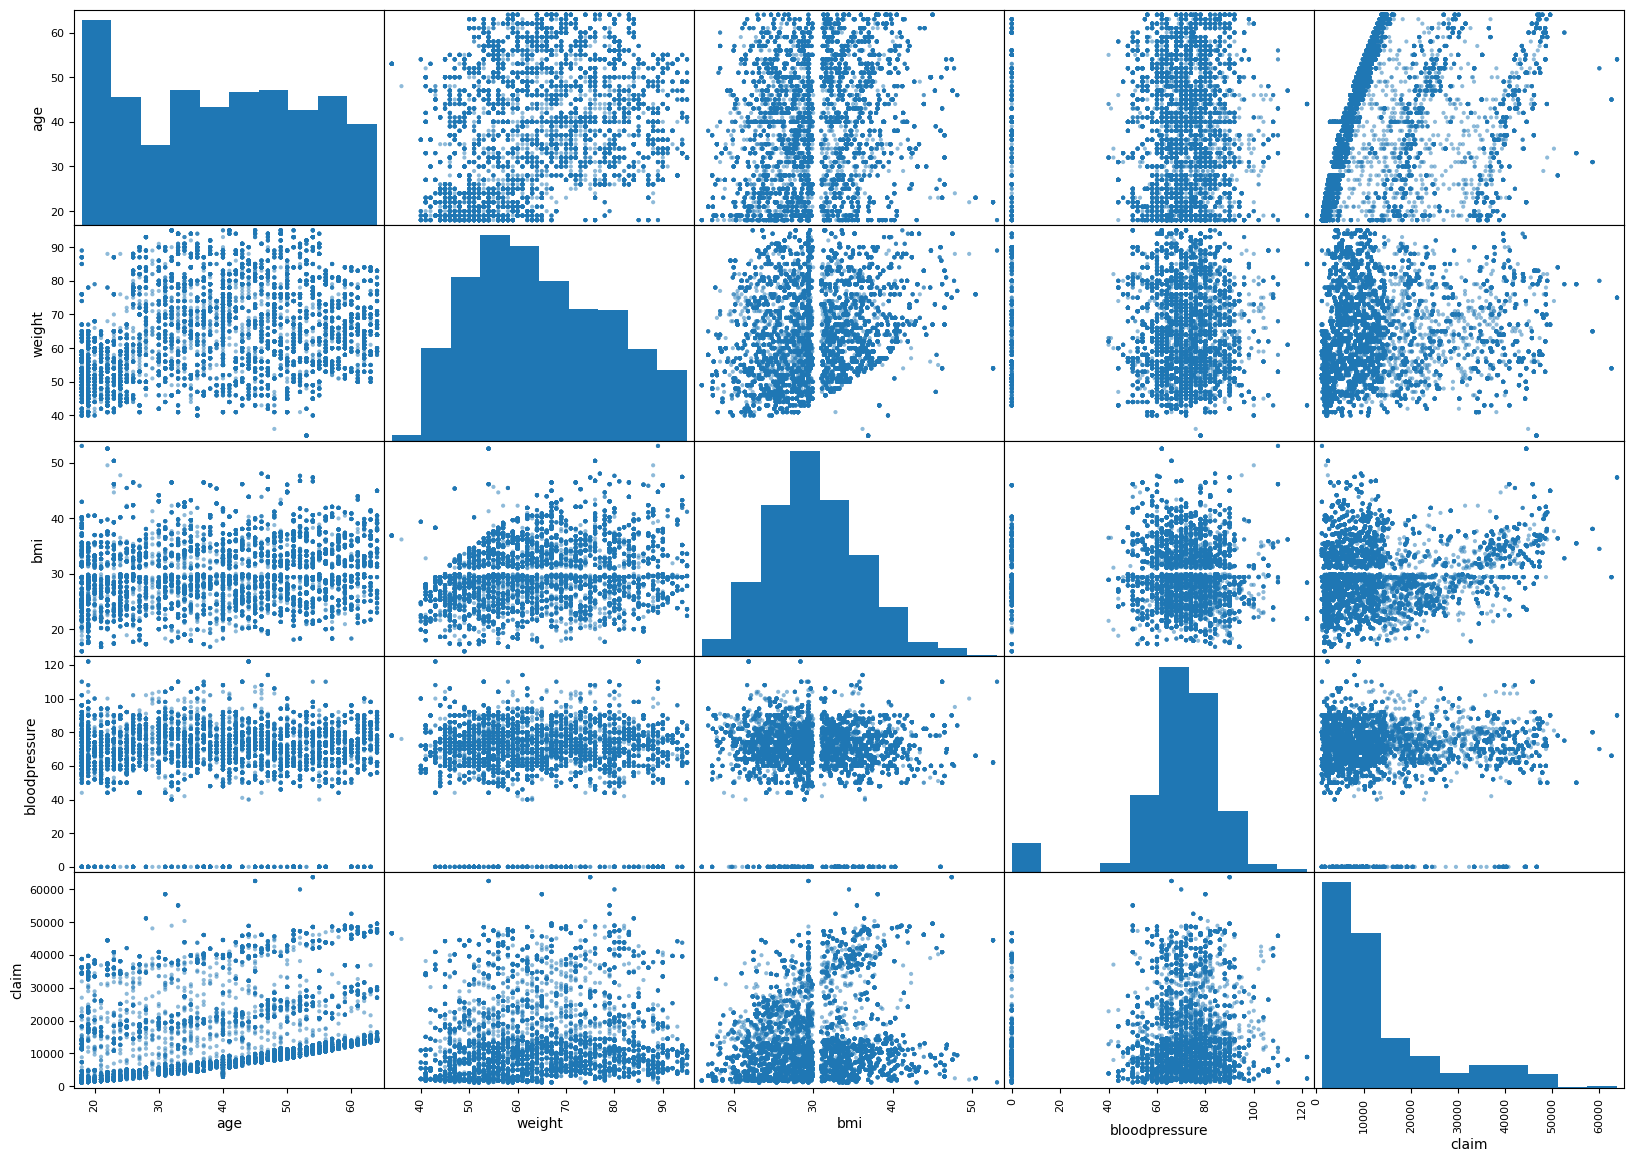

In [ ]:
scatter_matrix(df[attributes], figsize = (20,14))

# Making pipeline

In [ ]:
num_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy = 'median')),
    ('standardize', StandardScaler()),
])

In [ ]:
num_pipeline

Pipeline(steps=[('impute', SimpleImputer(strategy='median')),
                ('standardize', StandardScaler())])

In [ ]:
df_num_prepared = num_pipeline.fit_transform(df.select_dtypes(include = [np.number]))

In [ ]:
df.isnull().sum()

,0
age,0
sex,0
weight,0
bmi,0
hereditary_diseases,0
no_of_dependents,0
smoker,0
city,0
bloodpressure,0
diabetes,0


In [ ]:
df.head()

,age,sex,weight,bmi,hereditary_diseases,no_of_dependents,smoker,city,bloodpressure,diabetes,regular_ex,job_title,claim
0,60.0,male,64.0,24.3,NoDisease,1.0,0.0,NewYork,72.0,0.0,0.0,Actor,13112.6
1,49.0,female,75.0,22.6,NoDisease,1.0,0.0,Boston,78.0,1.0,1.0,Engineer,9567.0
2,32.0,female,64.0,17.8,Epilepsy,2.0,1.0,Phildelphia,88.0,1.0,1.0,Academician,32734.2
3,61.0,female,53.0,36.4,NoDisease,1.0,1.0,Pittsburg,72.0,1.0,0.0,Chef,48517.6
4,19.0,female,50.0,20.6,NoDisease,0.0,0.0,Buffalo,82.0,1.0,0.0,HomeMakers,1731.7


In [ ]:
target = 'claim'
cat_features = df.select_dtypes(include=['object']).columns.tolist()
num_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

if target in num_features:
    num_features.remove(target)

print("Categorical Features:", cat_features)
print("Numerical Features:", num_features)

Categorical Features: ['sex', 'hereditary_diseases', 'city', 'job_title']
Numerical Features: ['age', 'weight', 'bmi', 'no_of_dependents', 'smoker', 'bloodpressure', 'diabetes', 'regular_ex']


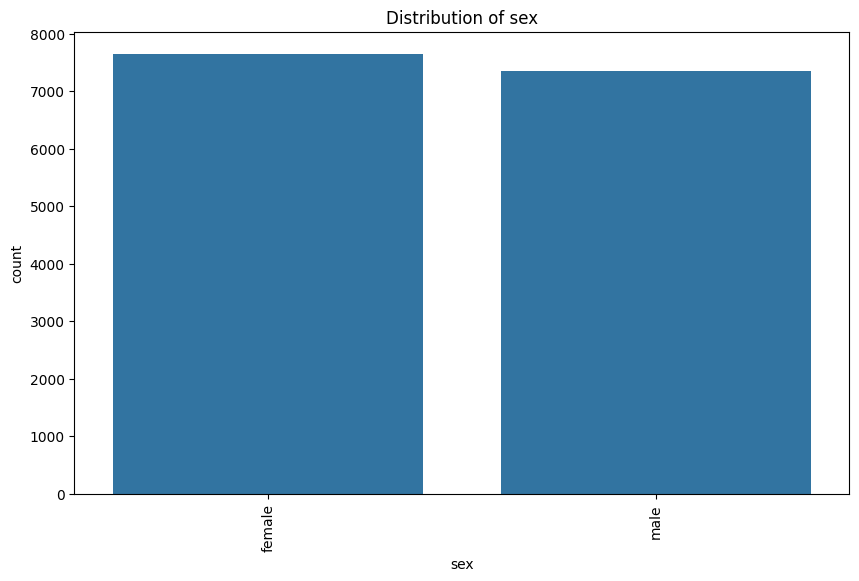

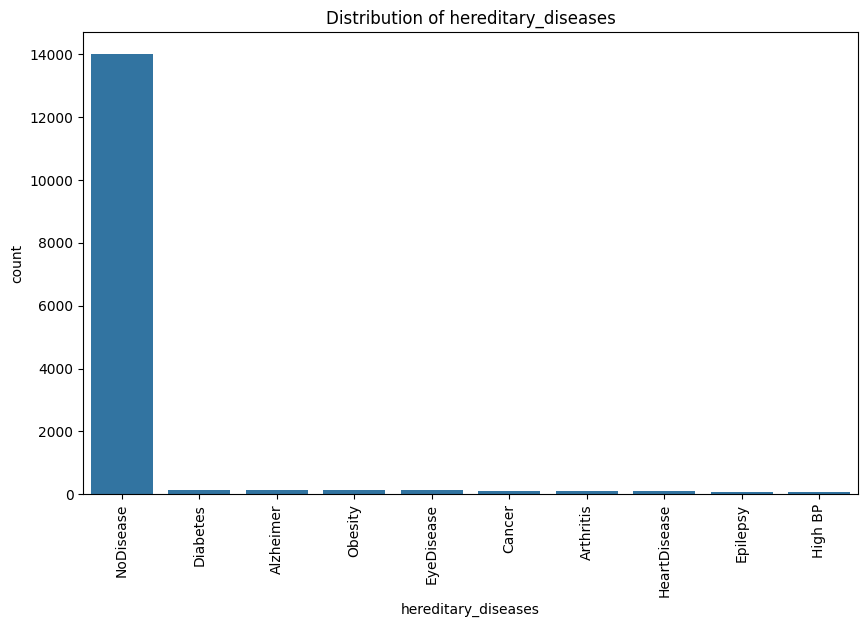

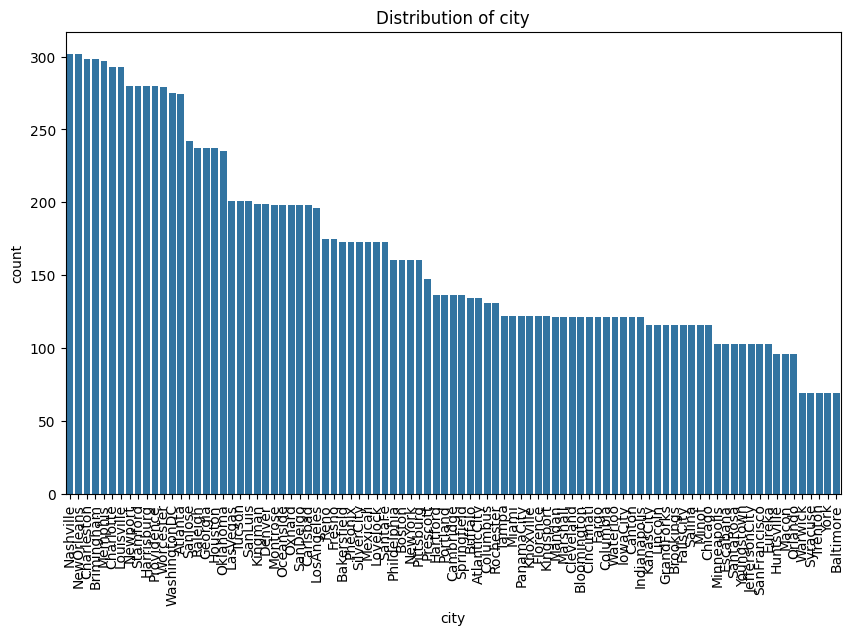

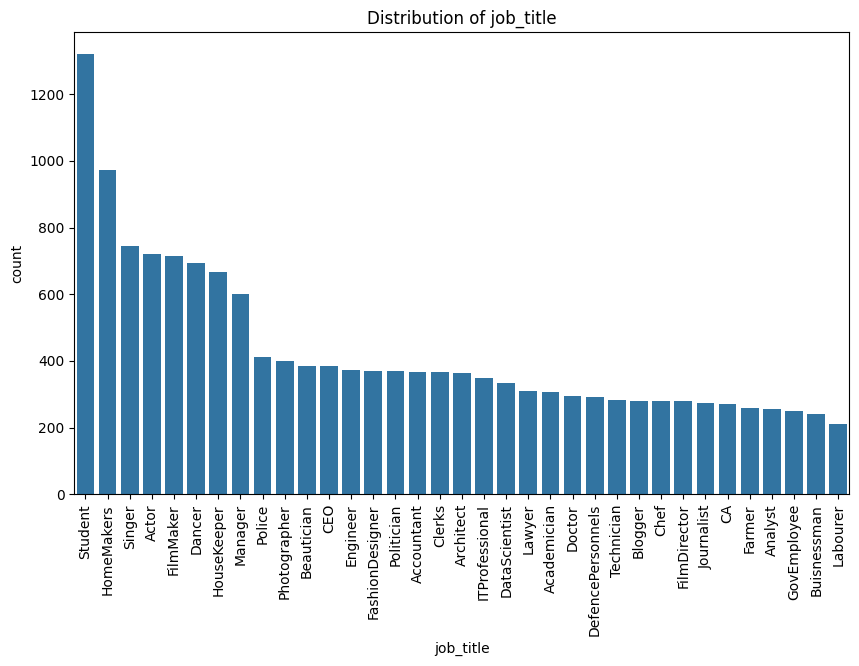

In [ ]:
for feature in cat_features:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=feature, order=df[feature].value_counts().index)
    plt.title(f'Distribution of {feature}')
    plt.xticks(rotation=90)
    plt.show()

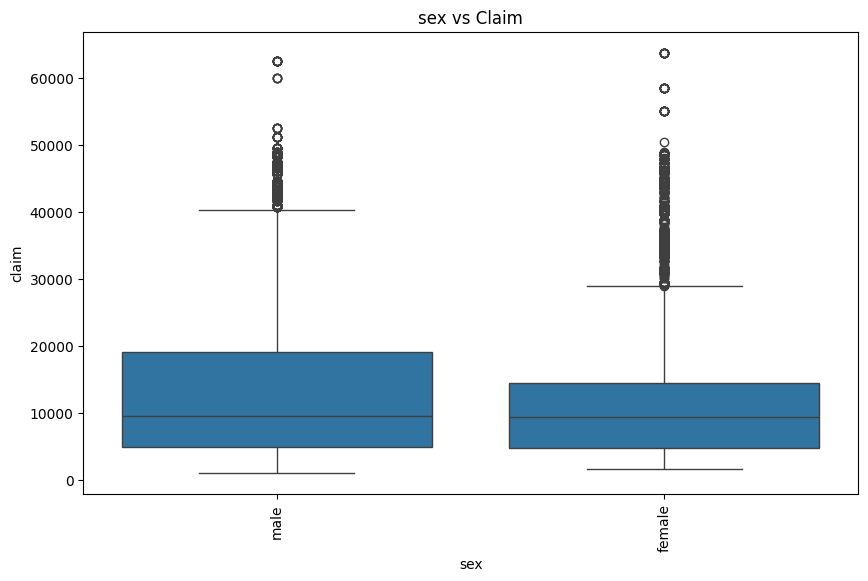

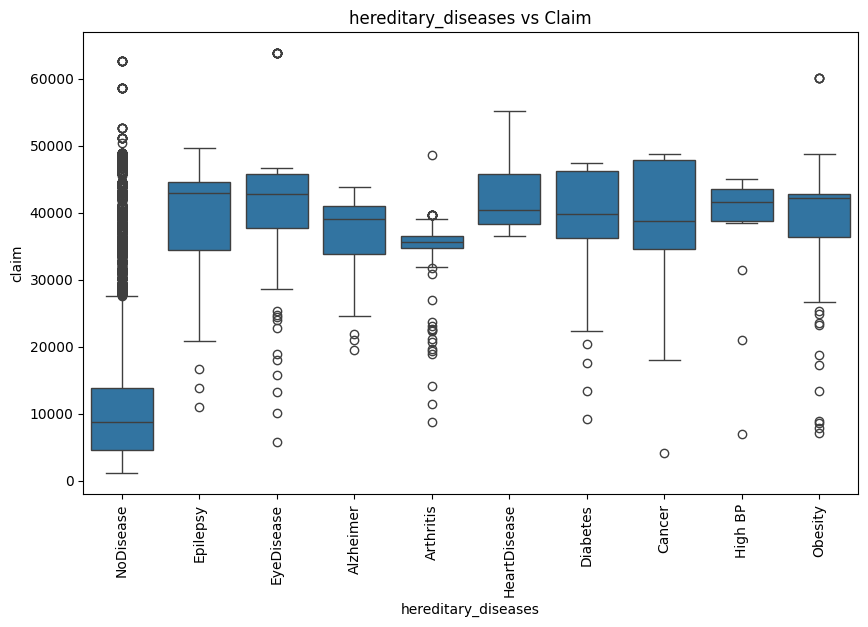

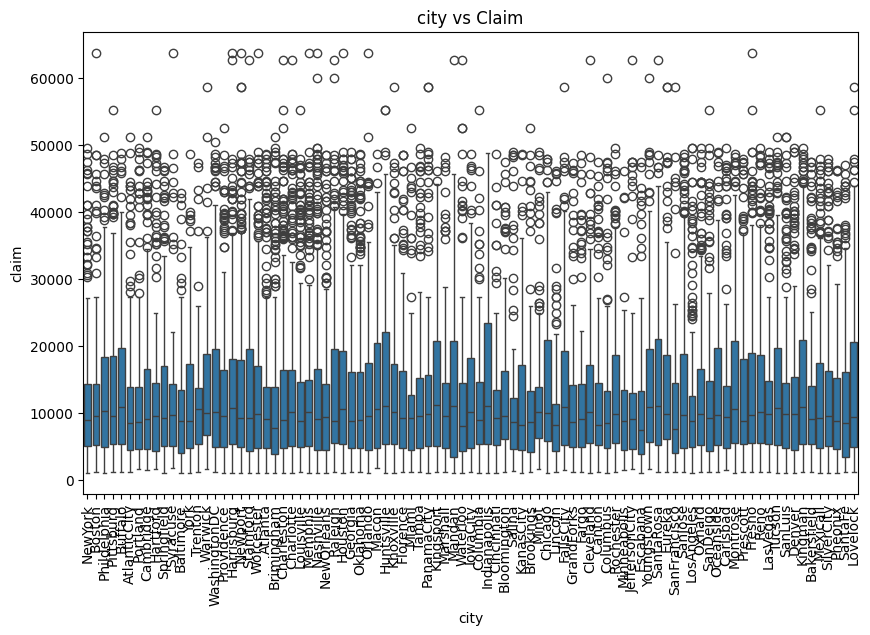

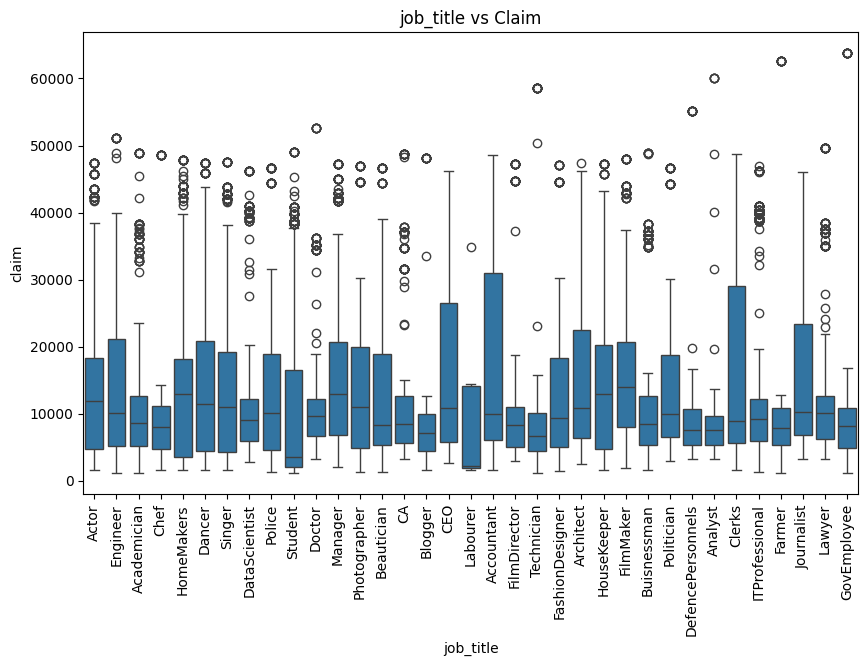

In [ ]:
for feature in cat_features:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x=feature, y=target)
    plt.title(f'{feature} vs Claim')
    plt.xticks(rotation=90)
    plt.show()

In [ ]:
X = df.drop(target,axis=1)
y = df[target]

In [ ]:
y_log = np.log1p(y)

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y_log,test_size=0.2,random_state=42)

In [ ]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((12000, 12), (3000, 12), (12000,), (3000,))

In [ ]:
num_transformer = Pipeline(steps=[
    ('scaler',StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('onehot',OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num',num_transformer,num_features),
    ('cat',cat_transformer,cat_features)
],remainder='passthrough')

pipeline = Pipeline(steps=[
    ('preprocessor',preprocessor)
])

X_train_transformed = pipeline.fit_transform(X_train)
X_test_transformed = pipeline.transform(X_test)

X_train_transformed = X_train_transformed.toarray()
X_test_transformed = X_test_transformed.toarray()

all_features = pipeline.named_steps['preprocessor'].get_feature_names_out()

X_train_transformed_df = pd.DataFrame(X_train_transformed,columns=all_features)
X_test_transformed_df = pd.DataFrame(X_test_transformed,columns=all_features)

In [ ]:
all_features

array(['num__age', 'num__weight', 'num__bmi', 'num__no_of_dependents',
       'num__smoker', 'num__bloodpressure', 'num__diabetes',
       'num__regular_ex', 'cat__sex_female', 'cat__sex_male',
       'cat__hereditary_diseases_Alzheimer',
       'cat__hereditary_diseases_Arthritis',
       'cat__hereditary_diseases_Cancer',
       'cat__hereditary_diseases_Diabetes',
       'cat__hereditary_diseases_Epilepsy',
       'cat__hereditary_diseases_EyeDisease',
       'cat__hereditary_diseases_HeartDisease',
       'cat__hereditary_diseases_High BP',
       'cat__hereditary_diseases_NoDisease',
       'cat__hereditary_diseases_Obesity', 'cat__city_Atlanta',
       'cat__city_AtlanticCity', 'cat__city_Bakersfield',
       'cat__city_Baltimore', 'cat__city_Bloomington', 'cat__city_Boston',
       'cat__city_Brimingham', 'cat__city_Brookings', 'cat__city_Buffalo',
       'cat__city_Cambridge', 'cat__city_Canton', 'cat__city_Carlsbad',
       'cat__city_Charleston', 'cat__city_Charlotte', 'cat__

In [ ]:
# len(df['job_title'].value_counts())

In [ ]:
# len(df['hereditary_diseases'].value_counts())

In [ ]:
# len(df['city'].value_counts())

In [ ]:
# cat_pipeline = make_pipeline(
#     SimpleImputer(strategy = 'most_frequent'),
#     OneHotEncoder(handle_unknown = 'ignore'))

# preprocessing = ColumnTransformer([
#     ('num', num_pipeline, num_attribs),
#     ('cat', cat_pipeline, cat_attribs),
# ])

In [ ]:
# preprocessing = make_column_transformer(
#     (num_pipeline, make_column_selector(dtype_include = np.number)),
#     (cat_pipeline, make_column_selector(dtype_include = object)),
# )

In [ ]:
# df_prepared = preprocessing.fit_transform(df)

In [ ]:
# preprocessing.get_feature_names_out()

In [ ]:
# df_prepared.head()

array([[<Axes: xlabel='age', ylabel='age'>,
        <Axes: xlabel='weight', ylabel='age'>,
        <Axes: xlabel='bmi', ylabel='age'>,
        <Axes: xlabel='bloodpressure', ylabel='age'>,
        <Axes: xlabel='claim', ylabel='age'>],
       [<Axes: xlabel='age', ylabel='weight'>,
        <Axes: xlabel='weight', ylabel='weight'>,
        <Axes: xlabel='bmi', ylabel='weight'>,
        <Axes: xlabel='bloodpressure', ylabel='weight'>,
        <Axes: xlabel='claim', ylabel='weight'>],
       [<Axes: xlabel='age', ylabel='bmi'>,
        <Axes: xlabel='weight', ylabel='bmi'>,
        <Axes: xlabel='bmi', ylabel='bmi'>,
        <Axes: xlabel='bloodpressure', ylabel='bmi'>,
        <Axes: xlabel='claim', ylabel='bmi'>],
       [<Axes: xlabel='age', ylabel='bloodpressure'>,
        <Axes: xlabel='weight', ylabel='bloodpressure'>,
        <Axes: xlabel='bmi', ylabel='bloodpressure'>,
        <Axes: xlabel='bloodpressure', ylabel='bloodpressure'>,
        <Axes: xlabel='claim', ylabel='bloodpres

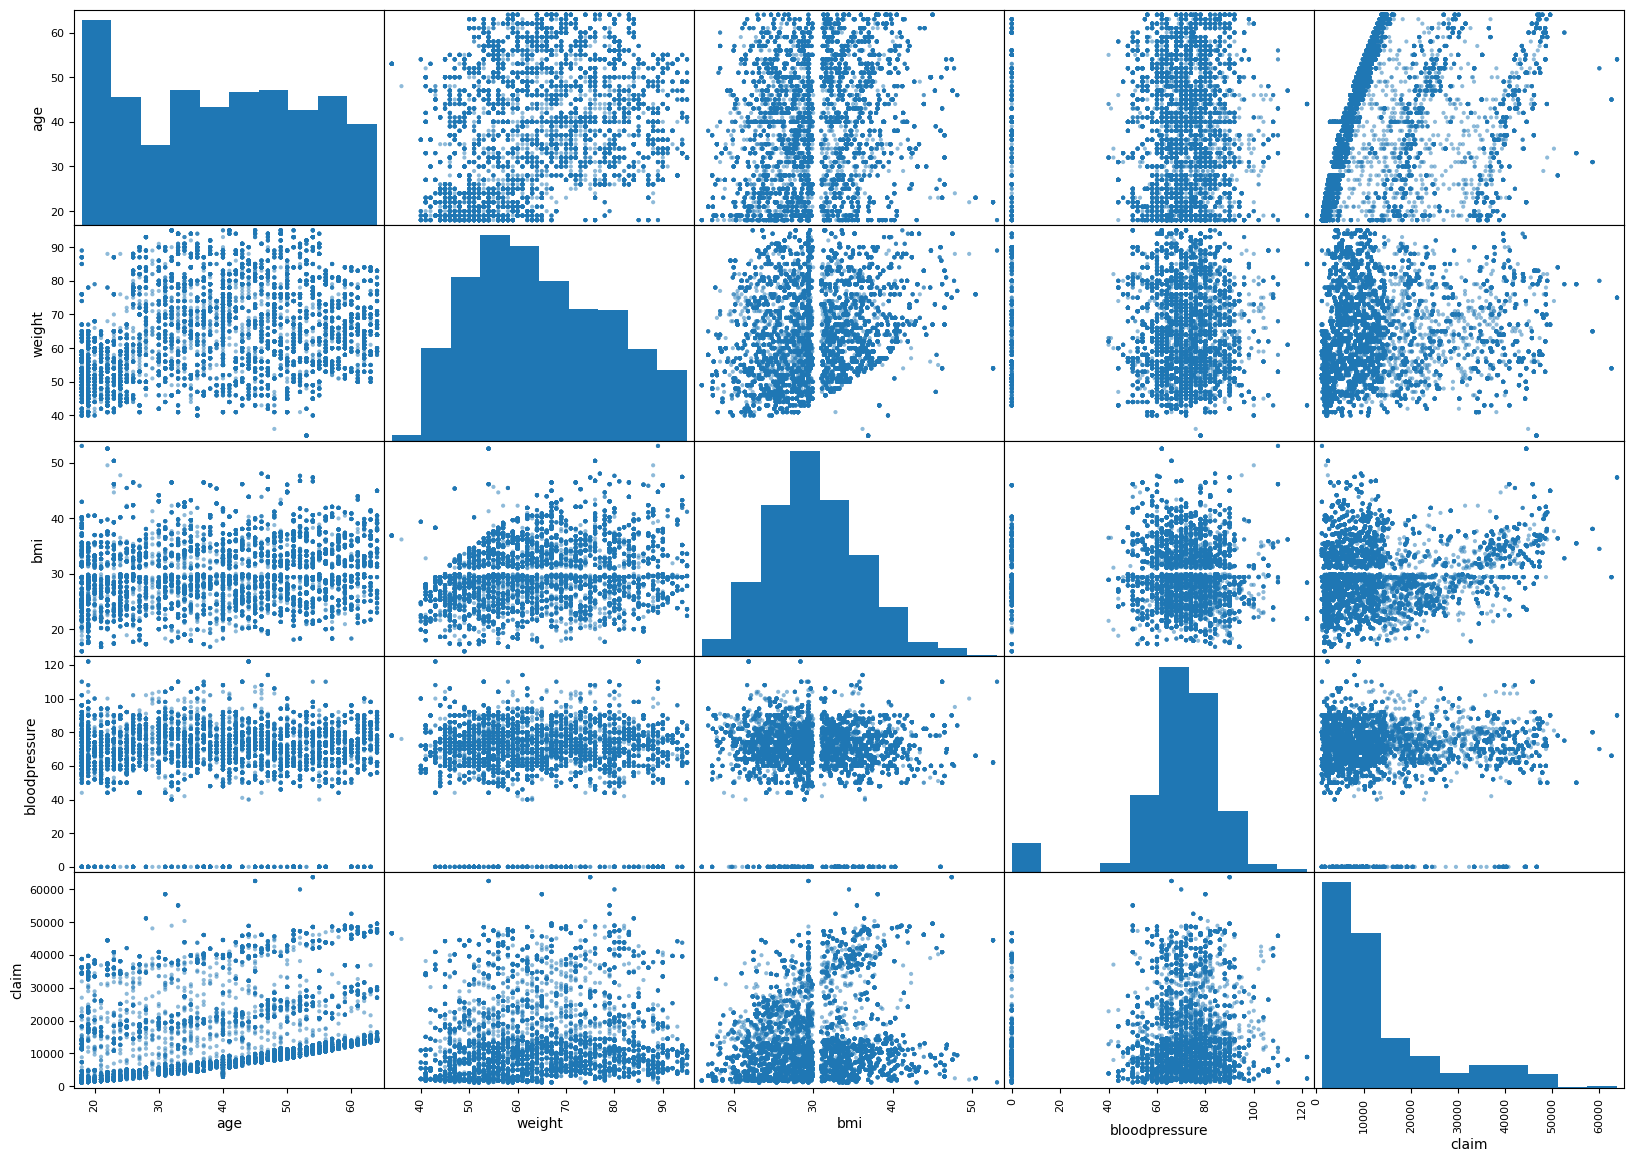

In [ ]:
scatter_matrix(df[attributes], figsize = (20,14))

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import joblib

# ============================================================================
# 1. DATA PREPARATION
# ============================================================================
target = 'claim'

# Select features (excluding target)
cat_features = df.select_dtypes(include=['object']).columns.tolist()
num_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_features.remove(target)

# Split features and target
X = df.drop(target, axis=1)
y = df[target]
y_log = np.log1p(y)  # Log transform for better distribution

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

# ============================================================================
# 2. PREPROCESSING PIPELINE (Reusable)
# ============================================================================
num_transformer = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
], remainder='drop')

# ============================================================================
# 3. MODEL PIPELINES (Industry Best Practice)
# ============================================================================
# Define multiple models to compare
models = {
    'Linear Regression': Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', LinearRegression())
    ]),

    'Ridge Regression': Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', Ridge(alpha=1.0))
    ]),

    'Lasso Regression': Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', Lasso(alpha=1.0))
    ]),

    'Random Forest': Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
    ]),

    'Gradient Boosting': Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', GradientBoostingRegressor(n_estimators=100, random_state=42))
    ])
}

# ============================================================================
# 4. MODEL TRAINING & EVALUATION
# ============================================================================
results = {}

print("="*80)
print("MODEL COMPARISON")
print("="*80)

for name, pipeline in models.items():
    print(f"\nTraining {name}...")

    # Cross-validation for robust evaluation
    cv_scores = cross_val_score(
        pipeline, X_train, y_train,
        cv=5,
        scoring='neg_mean_squared_error',
        n_jobs=-1
    )
    cv_rmse = np.sqrt(-cv_scores.mean())

    # Train on full training set
    pipeline.fit(X_train, y_train)

    # Predictions
    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)

    # Metrics (in log space)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    # Convert back to original scale for interpretation
    y_test_original = np.expm1(y_test)
    y_test_pred_original = np.expm1(y_test_pred)
    test_rmse_original = np.sqrt(mean_squared_error(y_test_original, y_test_pred_original))
    test_mae_original = mean_absolute_error(y_test_original, y_test_pred_original)

    results[name] = {
        'cv_rmse': cv_rmse,
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'test_mae': test_mae,
        'test_r2': test_r2,
        'test_rmse_original': test_rmse_original,
        'test_mae_original': test_mae_original,
        'pipeline': pipeline
    }

    print(f"  CV RMSE (log):        {cv_rmse:.4f}")
    print(f"  Train RMSE (log):     {train_rmse:.4f}")
    print(f"  Test RMSE (log):      {test_rmse:.4f}")
    print(f"  Test MAE (log):       {test_mae:.4f}")
    print(f"  Test R² Score:        {test_r2:.4f}")
    print(f"  Test RMSE (original): ${test_rmse_original:,.2f}")
    print(f"  Test MAE (original):  ${test_mae_original:,.2f}")

# ============================================================================
# 5. SELECT BEST MODEL
# ============================================================================
best_model_name = min(results, key=lambda x: results[x]['test_rmse'])
best_pipeline = results[best_model_name]['pipeline']

print("\n" + "="*80)
print(f"BEST MODEL: {best_model_name}")
print("="*80)
print(f"Test RMSE: ${results[best_model_name]['test_rmse_original']:,.2f}")
print(f"Test MAE:  ${results[best_model_name]['test_mae_original']:,.2f}")
print(f"Test R²:   {results[best_model_name]['test_r2']:.4f}")

# ============================================================================
# 6. HYPERPARAMETER TUNING (Optional - for best model)
# ============================================================================
print("\n" + "="*80)
print("HYPERPARAMETER TUNING")
print("="*80)

if best_model_name == 'Ridge Regression':
    param_grid = {
        'regressor__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]
    }
elif best_model_name == 'Random Forest':
    param_grid = {
        'regressor__n_estimators': [100, 200],
        'regressor__max_depth': [10, 20, None],
        'regressor__min_samples_split': [2, 5]
    }
elif best_model_name == 'Gradient Boosting':
    param_grid = {
        'regressor__n_estimators': [100, 200],
        'regressor__learning_rate': [0.01, 0.1],
        'regressor__max_depth': [3, 5]
    }
else:
    param_grid = {}

if param_grid:
    grid_search = GridSearchCV(
        models[best_model_name],
        param_grid,
        cv=5,
        scoring='neg_mean_squared_error',
        n_jobs=-1,
        verbose=1
    )

    print(f"Tuning {best_model_name}...")
    grid_search.fit(X_train, y_train)

    print(f"\nBest parameters: {grid_search.best_params_}")
    print(f"Best CV RMSE: {np.sqrt(-grid_search.best_score_):.4f}")

    # Update best pipeline
    best_pipeline = grid_search.best_estimator_

    # Re-evaluate on test set
    y_test_pred = best_pipeline.predict(X_test)
    y_test_pred_original = np.expm1(y_test_pred)
    y_test_original = np.expm1(y_test)

    test_rmse_tuned = np.sqrt(mean_squared_error(y_test_original, y_test_pred_original))
    test_mae_tuned = mean_absolute_error(y_test_original, y_test_pred_original)
    test_r2_tuned = r2_score(y_test, y_test_pred)

    print(f"\nTuned Model Performance:")
    print(f"  Test RMSE: ${test_rmse_tuned:,.2f}")
    print(f"  Test MAE:  ${test_mae_tuned:,.2f}")
    print(f"  Test R²:   {test_r2_tuned:.4f}")

# ============================================================================
# 7. SAVE MODEL (Production Ready)
# ============================================================================
print("\n" + "="*80)
print("SAVING MODEL")
print("="*80)

# Save the best pipeline
joblib.dump(best_pipeline, 'insurance_claim_model.pkl')
print("✓ Model saved as 'insurance_claim_model.pkl'")

# Save feature names for reference
feature_names = {
    'numerical': num_features,
    'categorical': cat_features,
    'target': target
}
joblib.dump(feature_names, 'feature_names.pkl')
print("✓ Feature names saved as 'feature_names.pkl'")

# ============================================================================
# 8. PREDICTION FUNCTION (For Production Use)
# ============================================================================
def predict_claim(model_path, data):
    """
    Predict insurance claim for new data

    Parameters:
    -----------
    model_path : str
        Path to saved model (.pkl file)
    data : pd.DataFrame
        Input data with same features as training data

    Returns:
    --------
    predictions : array
        Predicted claim amounts in original scale
    """
    model = joblib.load(model_path)
    predictions_log = model.predict(data)
    predictions = np.expm1(predictions_log)  # Convert back from log scale
    return predictions

# Example usage:
# sample_data = X_test.head()
# predictions = predict_claim('insurance_claim_model.pkl', sample_data)
# print(f"Predicted claims: {predictions}")

print("\n" + "="*80)
print("PIPELINE COMPLETE!")
print("="*80)
print("\nTo make predictions on new data:")
print("  predictions = predict_claim('insurance_claim_model.pkl', new_data)")

MODEL COMPARISON

Training Linear Regression...
  CV RMSE (log):        0.4593
  Train RMSE (log):     0.4533
  Test RMSE (log):      0.4648
  Test MAE (log):       0.3021
  Test R² Score:        0.7358
  Test RMSE (original): $8,774.48
  Test MAE (original):  $4,407.23

Training Ridge Regression...
  CV RMSE (log):        0.4592
  Train RMSE (log):     0.4533
  Test RMSE (log):      0.4648
  Test MAE (log):       0.3020
  Test R² Score:        0.7359
  Test RMSE (original): $8,771.29
  Test MAE (original):  $4,404.94

Training Lasso Regression...
  CV RMSE (log):        0.9083
  Train RMSE (log):     0.9081
  Test RMSE (log):      0.9045
  Test MAE (log):       0.7267
  Test R² Score:        -0.0001
  Test RMSE (original): $12,987.43
  Test MAE (original):  $8,395.43

Training Random Forest...
  CV RMSE (log):        0.1704
  Train RMSE (log):     0.0621
  Test RMSE (log):      0.1616
  Test MAE (log):       0.0368
  Test R² Score:        0.9681
  Test RMSE (original): $2,250.85
  Tes

MODEL COMPARISON

Training Linear Regression...
  CV RMSE (log):        0.4593
  Train RMSE (log):     0.4533
  Test RMSE (log):      0.4648
  Test MAE (log):       0.3021
  Test R² Score:        0.7358
  Test RMSE (original): $8,774.48
  Test MAE (original):  $4,407.23

Training Ridge Regression...
  CV RMSE (log):        0.4592
  Train RMSE (log):     0.4533
  Test RMSE (log):      0.4648
  Test MAE (log):       0.3020
  Test R² Score:        0.7359
  Test RMSE (original): $8,771.29
  Test MAE (original):  $4,404.94

Training Lasso Regression...
  CV RMSE (log):        0.9083
  Train RMSE (log):     0.9081
  Test RMSE (log):      0.9045
  Test MAE (log):       0.7267
  Test R² Score:        -0.0001
  Test RMSE (original): $12,987.43
  Test MAE (original):  $8,395.43

Training Random Forest...
  CV RMSE (log):        0.1704
  Train RMSE (log):     0.0621
  Test RMSE (log):      0.1616
  Test MAE (log):       0.0368
  Test R² Score:        0.9681
  Test RMSE (original): $2,250.85
  Tes

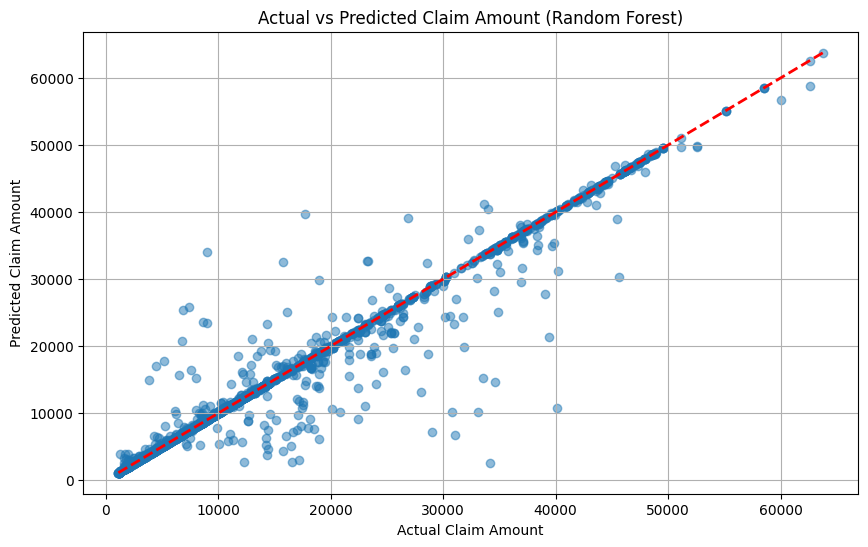

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================================
# 1. DATA PREPARATION
# ============================================================================
target = 'claim'

# Select features (excluding target)
cat_features = df.select_dtypes(include=['object']).columns.tolist()
num_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_features.remove(target)

# Split features and target
X = df.drop(target, axis=1)
y = df[target]
y_log = np.log1p(y)  # Log transform for better distribution

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

# ============================================================================
# 2. PREPROCESSING PIPELINE (Reusable)
# ============================================================================
num_transformer = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
], remainder='drop')

# ============================================================================
# 3. MODEL PIPELINES (Industry Best Practice)
# ============================================================================
# Define multiple models to compare
models = {
    'Linear Regression': Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', LinearRegression())
    ]),

    'Ridge Regression': Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', Ridge(alpha=1.0))
    ]),

    'Lasso Regression': Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', Lasso(alpha=1.0))
    ]),

    'Random Forest': Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
    ]),

    'Gradient Boosting': Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', GradientBoostingRegressor(n_estimators=100, random_state=42))
    ])
}

# ============================================================================
# 4. MODEL TRAINING & EVALUATION
# ============================================================================
results = {}

print("="*80)
print("MODEL COMPARISON")
print("="*80)

for name, pipeline in models.items():
    print(f"\nTraining {name}...")

    # Cross-validation for robust evaluation
    cv_scores = cross_val_score(
        pipeline, X_train, y_train,
        cv=5,
        scoring='neg_mean_squared_error',
        n_jobs=-1
    )
    cv_rmse = np.sqrt(-cv_scores.mean())

    # Train on full training set
    pipeline.fit(X_train, y_train)

    # Predictions
    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)

    # Metrics (in log space)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    # Convert back to original scale for interpretation
    y_test_original = np.expm1(y_test)
    y_test_pred_original = np.expm1(y_test_pred)
    test_rmse_original = np.sqrt(mean_squared_error(y_test_original, y_test_pred_original))
    test_mae_original = mean_absolute_error(y_test_original, y_test_pred_original)

    results[name] = {
        'cv_rmse': cv_rmse,
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'test_mae': test_mae,
        'test_r2': test_r2,
        'test_rmse_original': test_rmse_original,
        'test_mae_original': test_mae_original,
        'pipeline': pipeline
    }

    print(f"  CV RMSE (log):        {cv_rmse:.4f}")
    print(f"  Train RMSE (log):     {train_rmse:.4f}")
    print(f"  Test RMSE (log):      {test_rmse:.4f}")
    print(f"  Test MAE (log):       {test_mae:.4f}")
    print(f"  Test R² Score:        {test_r2:.4f}")
    print(f"  Test RMSE (original): ${test_rmse_original:,.2f}")
    print(f"  Test MAE (original):  ${test_mae_original:,.2f}")

# ============================================================================
# 5. SELECT BEST MODEL
# ============================================================================
best_model_name = min(results, key=lambda x: results[x]['test_rmse'])
best_pipeline = results[best_model_name]['pipeline']

print("\n" + "="*80)
print(f"BEST MODEL: {best_model_name}")
print("="*80)
print(f"Test RMSE: ${results[best_model_name]['test_rmse_original']:,.2f}")
print(f"Test MAE:  ${results[best_model_name]['test_mae_original']:,.2f}")
print(f"Test R²:   {results[best_model_name]['test_r2']:.4f}")

# ============================================================================
# 6. HYPERPARAMETER TUNING (Optional - for best model)
# ============================================================================
print("\n" + "="*80)
print("HYPERPARAMETER TUNING")
print("="*80)

if best_model_name == 'Ridge Regression':
    param_grid = {
        'regressor__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]
    }
elif best_model_name == 'Random Forest':
    param_grid = {
        'regressor__n_estimators': [100, 200],
        'regressor__max_depth': [10, 20, None],
        'regressor__min_samples_split': [2, 5]
    }
elif best_model_name == 'Gradient Boosting':
    param_grid = {
        'regressor__n_estimators': [100, 200],
        'regressor__learning_rate': [0.01, 0.1],
        'regressor__max_depth': [3, 5]
    }
else:
    param_grid = {}

if param_grid:
    grid_search = GridSearchCV(
        models[best_model_name],
        param_grid,
        cv=5,
        scoring='neg_mean_squared_error',
        n_jobs=-1,
        verbose=1
    )

    print(f"Tuning {best_model_name}...")
    grid_search.fit(X_train, y_train)

    print(f"\nBest parameters: {grid_search.best_params_}")
    print(f"Best CV RMSE: {np.sqrt(-grid_search.best_score_):.4f}")

    # Update best pipeline
    best_pipeline = grid_search.best_estimator_

    # Re-evaluate on test set
    y_test_pred = best_pipeline.predict(X_test)
    y_test_pred_original = np.expm1(y_test_pred)
    y_test_original = np.expm1(y_test)

    test_rmse_tuned = np.sqrt(mean_squared_error(y_test_original, y_test_pred_original))
    test_mae_tuned = mean_absolute_error(y_test_original, y_test_pred_original)
    test_r2_tuned = r2_score(y_test, y_test_pred)

    print(f"\nTuned Model Performance:")
    print(f"  Test RMSE: ${test_rmse_tuned:,.2f}")
    print(f"  Test MAE:  ${test_mae_tuned:,.2f}")
    print(f"  Test R²:   {test_r2_tuned:.4f}")

# ============================================================================
# 7. SAVE MODEL (Production Ready)
# ============================================================================
print("\n" + "="*80)
print("SAVING MODEL")
print("="*80)

# Save the best pipeline
joblib.dump(best_pipeline, 'insurance_claim_model.pkl')
print("✓ Model saved as 'insurance_claim_model.pkl'")

# Save feature names for reference
feature_names = {
    'numerical': num_features,
    'categorical': cat_features,
    'target': target
}
joblib.dump(feature_names, 'feature_names.pkl')
print("✓ Feature names saved as 'feature_names.pkl'")

# ============================================================================
# 8. PREDICTION FUNCTION (For Production Use)
# ============================================================================
def predict_claim(model_path, data):
    """
    Predict insurance claim for new data

    Parameters:
    -----------
    model_path : str
        Path to saved model (.pkl file)
    data : pd.DataFrame
        Input data with same features as training data

    Returns:
    --------
    predictions : array
        Predicted claim amounts in original scale
    """
    model = joblib.load(model_path)
    predictions_log = model.predict(data)
    predictions = np.expm1(predictions_log)  # Convert back from log scale
    return predictions

# Example usage:
# sample_data = X_test.head()
# predictions = predict_claim('insurance_claim_model.pkl', sample_data)
# print(f"Predicted claims: {predictions}")

print("\n" + "="*80)
print("PIPELINE COMPLETE!")
print("="*80)
print("\nTo make predictions on new data:")
print("  predictions = predict_claim('insurance_claim_model.pkl', new_data)")

# ============================================================================
# 9. ACTUAL vs PREDICTED PLOT (for best model)
# ============================================================================
plt.figure(figsize=(10, 6))
plt.scatter(y_test_original, y_test_pred_original, alpha=0.5)
plt.plot([y_test_original.min(), y_test_original.max()], [y_test_original.min(), y_test_original.max()], 'r--', lw=2)
plt.xlabel("Actual Claim Amount")
plt.ylabel("Predicted Claim Amount")
plt.title(f"Actual vs Predicted Claim Amount ({best_model_name})")
plt.grid(True)
plt.show()